In [1]:
import torch
import triton
import triton.language as tl
DEVICE = torch.device('cuda:0')

In [2]:
# fetching the properties of the GPU
properties = triton.runtime.driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM = properties["multiprocessor_count"]
NUM_REGS = properties["max_num_regs"] # total number of registers on a single SM
TOTAL_SRAM_PER_SM = properties["max_shared_mem"]
WARP_SIZE = properties["warpSize"]

print(properties)

{'max_shared_mem': 65536, 'max_num_regs': 65536, 'multiprocessor_count': 40, 'warpSize': 32, 'sm_clock_rate': 1590000, 'mem_clock_rate': 5001000, 'mem_bus_width': 256}


In [3]:
@triton.jit
def _layernorm_forward(
    x_ptr, y_ptr, weight_ptr, bias_ptr,
    mean_ptr, rstd_ptr,
    stride_M, N, eps,
    BLOCK_SIZE:tl.constexpr
):
  # ---------- FASTER APPROACH -----------
  row = tl.program_id(0)
  x_ptr += row * stride_M
  y_ptr += row * stride_M

  cols = tl.arange(0, BLOCK_SIZE)
  mask = cols < N

  x = tl.load(x_ptr + cols, mask=mask, other=0.0).to(tl.float32)

  mean = tl.sum(x, axis=0) / N

  diff = tl.where(cols < N, x - mean, 0.0)

  var = tl.sum(diff*diff, axis=0) / N
  rstd = 1 / (tl.sqrt(var + eps))

  tl.store(mean_ptr + row, mean)
  tl.store(rstd_ptr + row, rstd)

  w = tl.load(weight_ptr + cols, mask = mask, other=0.0)
  b = tl.load(bias_ptr + cols, mask = mask, other=0.0)

  x_normed = diff * rstd
  y = x_normed * w + b
  tl.store(y_ptr + cols, y, mask=mask)





  # ---------- TILED APPROACH ------------
  # row = tl.program_id(0)
  # x_ptr += row * stride_M
  # y_ptr += row * stride_M

  # sum_accumulator = tl.zeros([BLOCK_SIZE], dtype=tl.float32)
  # for offset in range(0, N, BLOCK_SIZE):
  #   cols = offset + tl.arange(0, BLOCK_SIZE)
  #   x = tl.load(x_ptr + cols, mask = cols < N, other=0.0).to(tl.float32)
  #   sum_accumulator += x

  # mean = tl.sum(sum_accumulator, axis=0) / N

  # acc = tl.zeros([BLOCK_SIZE], dtype=tl.float32)
  # for offset in range(0, N, BLOCK_SIZE):
  #   cols = offset + tl.arange(0, BLOCK_SIZE)
  #   x = tl.load(x_ptr + cols, mask = cols < N, other=0.0).to(tl.float32)
  #   diff = tl.where(cols < N, x - mean, 0.0) #masking before subtracting to avoid unnecessary subtraction from 0
  #   acc += diff * diff
  # var = tl.sum(acc, axis=0) / N
  # rstd = 1 / (tl.sqrt(var + eps))

  # # mean_ptr is the base_address of the variable and row is the program_id added to get the physical address
  # tl.store(mean_ptr + row, mean)
  # tl.store(rstd_ptr + row, rtsd)


  # for offset in range(0, N, BLOCK_SIZE):
  #   cols = offset + tl.arange(0, BLOCK_SIZE)
  #   mask = cols < N
  #   x = tl.load(x_ptr + cols, mask = mask, other=0.0)
  #   w = tl.load(w_ptr + cols, mask = mask, other=0.0)
  #   b = tl.load(b_ptr + cols, mask = mask, other=0.0)

  #   x_normed = (x - mean) * rstd
  #   y = x_normed * w + b
  #   tl.store(y_ptr + cols, y, mask=mask)





In [4]:
@triton.jit
def _layernorm_backward_dldx(
    x_ptr, dldx_ptr, dldy_ptr, w_ptr,
    mean_ptr, rstd_ptr,
    stride, N,
    locks_ptr, dldw_intermediate_ptr, dldb_intermediate_ptr,
    BLOCK_SIZE_N: tl.constexpr,
    GROUP_SIZE: tl.constexpr
):
  PID = tl.program_id(0)
  cols = tl.arange(0, BLOCK_SIZE_N)
  mask = cols < N
  x_ptr += PID * stride #calculate the starting position of the particular row handled by the PID by jumping "stride" elements
  dldx_ptr += PID * stride
  dldy_ptr += PID * stride

  #loading data into SRAM
  x = tl.load(x_ptr + cols, mask=mask, other=0.0).to(tl.float32)
  dldy = tl.load(dldy_ptr + cols, mask=mask, other=0.0).to(tl.float32)
  w = tl.load(w_ptr + cols, mask=mask).to(tl.float32)
  mean = tl.load(mean_ptr + PID)
  rstd = tl.load(rstd_ptr + PID)

  #computation of dldx
  x_normalized = tl.where(mask, (x - mean)*rstd, 0.0) # shape(BLOCKSIZE_N)
  dydx_norm = tl.where(mask, dldy * w, 0.0) # shape(BLOCKSIZE_N)
  c1 = tl.sum(x_normalized * dydx_norm, axis=0)/N # shape(1)
  c2 = tl.sum(dydx_norm, axis=0)/N # shape(1)
  dldx = (dydx_norm - (c1 * x_normalized + c2)) * rstd #shape(BLOCKSIZE_N)

  #writing back to DRAM
  tl.store(dldx_ptr + cols, dldx, mask=mask)

  #----------------dl/dx calculation done------------------------------

  dldw_contribution = (dldy * x_normalized).to(w.dtype)
  dldb_contribution = (dldy).to(w.dtype)

  lock_id = PID % GROUP_SIZE
  locks_ptr += lock_id # gives the address of locks[lock_id]
  # address of the second half of the locks array corresponding to the lock_id e.g., lock_id = 0 then count_ptr = 0 + 8 = 8
  count_ptr = locks_ptr + GROUP_SIZE

  dldw_inter_ptrs = dldw_intermediate_ptr + lock_id * N + cols # base address + pointers to the particular row to write data to
  dldb_inter_ptrs = dldb_intermediate_ptr + lock_id * N + cols

  # (lock[lock_id], expected, new)
  # if at lock[lock_id], the value read by a PID is 0, then it writes 1 at lock[lock_id]
  # returns the previous value (i.e., 0) and then checks in the while loop if 0 == 1 which becomes false after which loop is exited
  while tl.atomic_cas(locks_ptr, 0, 1) == 1:
    #if another PID tries to access it while it is locked, then the value read at lock[lock_id] will be 1 which wont be the expected 0
    # so it writes nothing at that location of the locks array and returns 1 which makes the condition true and that PID will be stuck in the loop
    # waiting for the previous PID to unlock it using tl.xchg(locks_ptr, 0) at the end of the kernel after it finishes writing
    pass

  count = tl.load(count_ptr) # fetch the value of the number of counts data has been written
  if count == 0: #no other PID has written to this row
    #write the value as 1 so that the other ptr knows that it has previously been written
    #so it first reads it, add and then write it again to that row
    tl.atomic_xchg(count_ptr, 1)

  else: #if its previosuly been written, add the previous values
    dldw_contribution += tl.load(dldw_inter_ptrs, mask=mask)
    dldb_contribution += tl.load(dldb_inter_ptrs, mask=mask)

  tl.store(dldw_inter_ptrs, dldw_contribution, mask=mask)
  tl.store(dldb_inter_ptrs, dldb_contribution, mask=mask)

  tl.atomic_xchg(locks_ptr, 0) # unlock after writing

In [5]:
@triton.jit
def _layernorm_backward_dldw_dldb(
    dldw_intermediate_ptr, dldb_intermediate_ptr,
    dldw_ptr, dldb_ptr,
    GROUP_SIZE, N,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr
):
  PID = tl.program_id(0) # splitted wrt columns
  # since BLOCK_SIZE_N = 32 and there are PIDs from 0 to 3
  # PID 0 --> cols = [0,.....,31]
  # PID 1 --> cols = [32,.....,63]
  # PID 2 --> cols = [64,.....,95]
  # PID 3 --> cols = [96,.....,128]
  col_ptrs = PID * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N) # each PID handling respective columns

  #accumulating the values as tiles
  dldw_acc = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N),dtype=tl.float32)
  dldb_acc = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N),dtype=tl.float32)

  #suppose BLOCK_SIZE_M = 32 & GROUP_SIZE = 64
  # loop iterates through [0, 32, 64 (not included)] => 2 iterations; i = 0 & i = 32
  # i = 0 (1st iter) -> row_ptrs = [0,.....,BLOCK_SIZE_M] = [0,.....,31]
  # i = 32 (2nd iter) -> row_ptrs = [0+i,......,BLOCK_SIZE_M + i] = [32,.....,63]
  for i in range(0, GROUP_SIZE, BLOCK_SIZE_M):
    row_ptrs = i + tl.arange(0, BLOCK_SIZE_M) # i + [0,......,31]

    #row_ptrs[:,None] = shape(BLOCK_SIZE_M, 1)
    #col_ptrs[None,:] = shape(1, BLOCK_SIZE_N)
    #2D mask is shape (BLOCK_SIZE_M, BLOCK_SIZE_N) is created
    #checking against the actual dimensions which is GROUP_SIZE and N
    #because BLOCK_SIZE_M and BLOCK_SIZE_N would always return true for the mask
    #mask only comes in handy if either row_ptrs & col_ptrs have values exceeding the GROUP_SIZE or N respectively
    mask = (row_ptrs[:,None] < GROUP_SIZE) & (col_ptrs[None,:] < N)

    # row_ptrs -> shape(BLOCK_SIZE_M, 1) = (32,1)
    # col_ptrs -> shape(1, BLOCK_SIZE_N) = (1,32)

    # row_ptrs[:, None] * N:                  # shape (32, 1) * 512

    # [[0   * 512],     [[0   ],
    #  [1   * 512],  =   [512 ],
    #  [2   * 512],      [1024],
    #  ...                ...
    #  [31  * 512]]      [15872]]

    # col_ptrs[None, :]:                      # shape (1, 32)
    # [[0, 1, 2, 3, ..., 31]]

    # Adding them together via broadcasting:
    # [[0    + 0,   0    + 1,   0    + 2,   ..., 0    + 31],   ← row 0
    #  [512  + 0,   512  + 1,   512  + 2,   ..., 512  + 31],   ← row 1
    #  [1024 + 0,   1024 + 1,   1024 + 2,   ..., 1024 + 31],   ← row 2
    #  ...
    #  [15872+ 0,   15872+ 1,   15872+ 2,   ..., 15872+ 31]]   ← row 31

    # Final offsets (32, 32):
    # [[0,    1,    2,    ..., 31  ],
    #  [512,  513,  514,  ..., 543  ],
    #  [1024, 1025, 1026, ...,  1055],
    #  ...
    #  [15872,15873,15874,..., 15893]]
    offsets = row_ptrs[:,None] * N + col_ptrs[None,:]

    dldw_acc += tl.load(dldw_intermediate_ptr + offsets, mask=mask, other=0.)
    dldb_acc += tl.load(dldb_intermediate_ptr + offsets, mask=mask, other=0.)


  sum_dLdw = tl.sum(dldw_acc, axis=0) # shape (BLOCK_SIZE_N)
  sum_dLdb = tl.sum(dldb_acc, axis=0)

  # Write the final sum computed by each PID to the output.
  tl.store(dldw_ptr + col_ptrs, sum_dLdw, mask=col_ptrs < N)
  tl.store(dldb_ptr + col_ptrs, sum_dLdb, mask=col_ptrs < N)

In [6]:
class LayerNorm(torch.autograd.Function):
  @staticmethod
  def forward(ctx, x, normalized_shape, weight, bias, eps):
    # x = [32, 512, 768] --> (32 Sentences, 512 Words each, 768 Hidden Units)
    # x.shape[-1] = 768 (last dimension)
    # x.reshape(-1, 768) => x = [32 x 512, 768] = [16384, 768]
    # M = 16384, N = 768
    M, N = x.reshape(-1, x.shape[-1]).shape

    # store the output and the mean and (reciprocal) std deviation (rstd) on the DRAM instead of SRAM for backward pass computation
    y = torch.empty_like(x)
    mean = torch.empty((M,), dtype=torch.float32, device=x.device)
    rstd = torch.empty((M,), dtype=torch.float32, device=x.device)

    # maximum number of elements (float32 or some other type) of each row that can be held in SRAM of each SM
    # given each SM's SRAM is of capacity "TOTAL_SRAM_PER_SM"
    MAX_FUSED_SIZE = TOTAL_SRAM_PER_SM // x.element_size()

    # make the blocksize to handle the elements not exceeding the max each SM can handle
    BLOCK_SIZE = min(MAX_FUSED_SIZE, triton.next_power_of_2(N))

    if N > BLOCK_SIZE:
      raise RuntimeError("this layernorm does not support features dim >= 64kb")

    # keep the warps for each block to be between 1 and 8 with a scaling factor of 8
    num_warps = min(max(BLOCK_SIZE // 256, 1), 8)

    # the grid can have programs equal to the number of rows
    _layernorm_forward[(M,)](
        x, y,
        weight, bias,
        mean, rstd,
        x.stride(0), N, eps,
        BLOCK_SIZE=BLOCK_SIZE, num_warps=num_warps
    )

    ctx.save_for_backward(x, weight, bias, mean, rstd)
    ctx.BLOCK_SIZE = BLOCK_SIZE
    ctx.num_warps = num_warps
    ctx.eps = eps

    return y


  @staticmethod
  def backward(ctx, dLdy):
    x,w,b,mean,rstd = ctx.saved_tensors
    M, N = x.reshape(-1, x.shape[-1]).shape

    dLdx = torch.empty_like(x) #(M,N)
    dLdw = torch.empty_like(w) #(N)
    dLdb = torch.empty_like(b) #(N)

    GROUP_SIZE = 64
    if N <= 8192: GROUP_SIZE = 96
    if N <= 4096: GROUP_SIZE = 128
    if N <= 1024: GROUP_SIZE = 256

    dldw_intermediate = torch.zeros((GROUP_SIZE, N), dtype=x.dtype, device=w.device)
    dldb_intermediate = torch.zeros((GROUP_SIZE, N), dtype=x.dtype, device=w.device)

    locks = torch.zeros(2*GROUP_SIZE, dtype=torch.int32, device=w.device)

    _layernorm_backward_dldx[(M,)](
        x, dLdx, dLdy,
        w, mean, rstd,
        x.stride(0), N,
        locks, dldw_intermediate, dldb_intermediate,
        BLOCK_SIZE_N = ctx.BLOCK_SIZE,
        GROUP_SIZE = GROUP_SIZE,
        num_warps = ctx.num_warps,
    )

    # second kernel to be parallelized across the cols
    # for example if N = 128 and BLOCK_SIZE_N = 32
    # grid would have 4 PIDs
    # pid 0 -> handles COLS [0:32]
    # pid 1 -> handles COLS [32:64]
    # pid 2 -> handles COLS [64:96]
    # pid 3 -> handles COLS [96:128]

    grid = lambda meta : [triton.cdiv(N, meta["BLOCK_SIZE_N"])]
    _layernorm_backward_dldw_dldb[grid](
        dldw_intermediate, dldb_intermediate,
        dLdw, dLdb,
        min(GROUP_SIZE, M), N,
        BLOCK_SIZE_M=32, BLOCK_SIZE_N = 128, # to handle each tile of intermediate matrices
    )

    return dLdx, None, dLdw, dLdb, None

layernorm = LayerNorm.apply



In [7]:
def test_layernorm_kernel(M, N, dtype, eps=1e-5, device=DEVICE):
  x = -2.3 + 0.5 * torch.randn((M,N), dtype=dtype, device=device) #normal distribution scaled by 0.5 and shifted 2.3 to the right
  x.requires_grad_(True)
  weight = torch.rand((N,), dtype=dtype, device=device, requires_grad=True)
  bias = torch.rand((N,), dtype=dtype, device=device, requires_grad=True)

  # forward pass
  y_tri = layernorm(x, (N,), weight, bias, eps)
  y_ref = torch.nn.functional.layer_norm(x, (N,), weight, bias, eps).to(dtype)
  torch.testing.assert_close(y_tri, y_ref, atol=1e-2, rtol=0)
  print("PASSED FORWARD PASS")

  # backward pass
  dLdy = 0.1 * torch.randn_like(x) # sample gradient of the loss wrt layernorm output

  y_tri.backward(dLdy, retain_graph=True) # calculates dl/dx, dl/dw, dl/db
  dldx_tri, dldw_tri, dldb_tri = [_.grad.clone() for _ in [x, weight, bias]]
  x.grad, weight.grad, bias.grad = None, None, None # clear the computed gradients

  y_ref.backward(dLdy, retain_graph=True) # calculates dl/dx, dl/dw, dl/db
  dldx_ref, dldw_ref, dldb_ref = [_.grad.clone() for _ in [x, weight, bias]]


  torch.testing.assert_close(dldx_tri, dldx_ref, atol=1e-2, rtol=0)
  torch.testing.assert_close(dldw_tri, dldw_ref, atol=1e-2, rtol=0)
  torch.testing.assert_close(dldb_tri, dldb_ref, atol=1e-2, rtol=0)
  print("PASSED BACKWARD PASS")

In [8]:
test_layernorm_kernel(1151, 8192, torch.float16)

PASSED FORWARD PASS
PASSED BACKWARD PASS


In [23]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[512 * i for i in range(2, 32)], # if you increase past 32 the kernel will break since features become larger than 64kb
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'Torch'],
        styles=[('blue', '-'), ('green', '-')],
        xlabel='No. of Features (Back Propogation)',
        ylabel='GB/s',
        plot_name='layer-norm-backward',
        args={'M': 4096, 'dtype': torch.float16, 'mode': 'backward'}, # so we're actually only benchmarking the backward pass
    ))
def benchmark_backprop(M, N, dtype, provider, mode='backward', eps=1e-5, device=DEVICE):
    # create data
    x_shape = (M, N)
    w_shape = (N, )
    weight = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    bias = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    x = -2.3 + 0.5 * torch.randn(x_shape, dtype=dtype, device=device)#, requires_grad=True)
    dLdy = .1 * torch.randn_like(x)
    x.requires_grad_(True)
        # setting this here instead of x's initial definition means the graph doesn't have to move through the -2.3 and 0.5 operations
    quantiles = [0.5, 0.05, 0.95]

    def y_fwd():
        if provider == "triton":
            return layernorm(x, w_shape, weight, bias, eps)
        if provider == "torch":
            return torch.nn.functional.layer_norm(x, w_shape, weight, bias, eps)

    # forward pass
    if mode == 'forward':
        gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        ms, min_ms, max_ms = triton.testing.do_bench(y_fwd, quantiles=quantiles, rep=500)
    # backward pass
    if mode == 'backward':
        y = y_fwd()
        gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)  # noqa: F811, E704
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: y.backward(dLdy, retain_graph=True), quantiles=quantiles,
                                                     grad_to_none=[x], rep=500)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

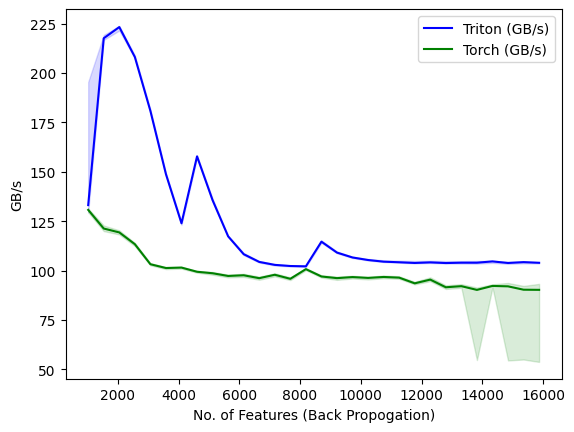

In [24]:
import matplotlib.pyplot as plt

benchmark_backprop.run(show_plots=True)

In [21]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[512 * i for i in range(2, 32)], # if you increase past 32 the kernel will break since features become larger than 64kb
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'Torch'],
        styles=[('blue', '-'), ('green', '-')],
        xlabel='No. of Features (Forward Pass)',
        ylabel='GB/s',
        plot_name='layer-norm-forward',
        args={'M': 4096, 'dtype': torch.float16, 'mode': 'forward'}, # so we're actually only benchmarking the backward pass
    ))
def benchmark_forward(M, N, dtype, provider, mode='forward', eps=1e-5, device=DEVICE):
    # create data
    x_shape = (M, N)
    w_shape = (N, )
    weight = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    bias = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    x = -2.3 + 0.5 * torch.randn(x_shape, dtype=dtype, device=device)#, requires_grad=True)
    dLdy = .1 * torch.randn_like(x)
    x.requires_grad_(True)
        # setting this here instead of x's initial definition means the graph doesn't have to move through the -2.3 and 0.5 operations
    quantiles = [0.5, 0.05, 0.95]

    def y_fwd():
        if provider == "triton":
            return layernorm(x, w_shape, weight, bias, eps)
        if provider == "torch":
            return torch.nn.functional.layer_norm(x, w_shape, weight, bias, eps)

    # forward pass
    if mode == 'forward':
        gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        ms, min_ms, max_ms = triton.testing.do_bench(y_fwd, quantiles=quantiles, rep=500)
    # backward pass
    if mode == 'backward':
        y = y_fwd()
        gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)  # noqa: F811, E704
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: y.backward(dLdy, retain_graph=True), quantiles=quantiles,
                                                     grad_to_none=[x], rep=500)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

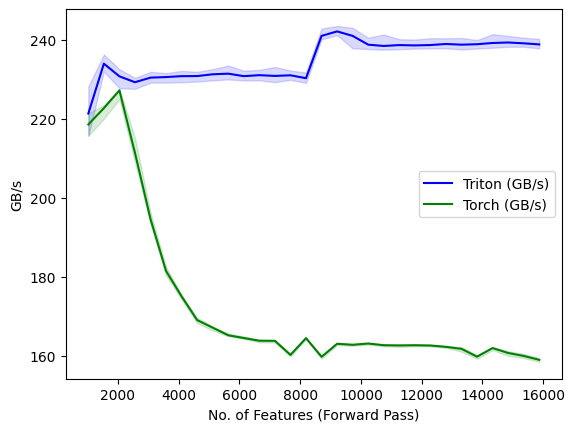

In [22]:
benchmark_forward.run(show_plots=True)